# ANN-based Surrogate Architecture Search

## Set up Dependencies

In [1]:
import json
import numpy as np
import os
from pprint import pprint
import scipy
from statistics import mean, stdev
from typing import List, Dict, Callable

In [2]:
import matplotlib.pyplot as plt
plt.rcParams["figure.dpi"] = 100 # TODO: Change DPI before submitting paper.

In [3]:
import pandas as pd

In [4]:
def printb(text: str) -> None:
    print("\033[1m" + text + "\033[0m")

## Data Analysis Functions

In [5]:
def plot_rank_correlation_as_lines(df: pd.DataFrame, target_path: str = None, plot_std: bool = True, anchor_yaxis: bool = True) -> None:
    ax = plt.subplot()

    for layer_count in df["layer_count"].unique():
        rel_df = df[df["layer_count"] == layer_count]

        ax.plot(rel_df["elements_per_layer"], rel_df["median_rank_correlation"], label=f"{layer_count} layers", linewidth=1)

        if plot_std:
            lower_bound = rel_df["median_rank_correlation"] - rel_df["stdev_rank_correlation"]
            upper_bound = rel_df["median_rank_correlation"] + rel_df["stdev_rank_correlation"]
            ax.fill_between(
                rel_df["elements_per_layer"], lower_bound, upper_bound, alpha=0.2
            )

    if anchor_yaxis:
            ax.set_ylim(0)

    ax.set_xlabel("elements per layer")
    ax.set_ylabel("rank correlation")

    plt.grid()
    plt.legend()

    if target_path is not None:
        plt.savefig(target_path, bbox_inches='tight')
        
    plt.show()
    plt.clf()

In [6]:
def plot_mse_as_lines(df: pd.DataFrame, target_path: str = None, plot_std: bool = True, anchor_yaxis: bool = True) -> None:
    ax = plt.subplot()

    for layer_count in df["layer_count"].unique():
        rel_df = df[df["layer_count"] == layer_count]

        ax.plot(rel_df["elements_per_layer"], rel_df["median_mse_score"], label=f"{layer_count} layers", linewidth=1)

        if plot_std:
            lower_bound = rel_df["median_mse_score"] - rel_df["stdev_mse_score"]
            upper_bound = rel_df["median_mse_score"] + rel_df["stdev_mse_score"]
            ax.fill_between(
                rel_df["elements_per_layer"], lower_bound, upper_bound, alpha=0.2
            )

    if anchor_yaxis:
            ax.set_ylim(0)

    ax.set_xlabel("elements per layer")
    ax.set_ylabel("mean squared error")

    plt.grid()
    plt.legend()

    if target_path is not None:
        plt.savefig(target_path, bbox_inches='tight')
        
    plt.show()
    plt.clf()

In [7]:
def plot_train_time_as_lines(df: pd.DataFrame, target_path: str = None, plot_std: bool = True, anchor_yaxis: bool = True) -> None:
    ax = plt.subplot()

    for layer_count in df["layer_count"].unique():
        rel_df = df[df["layer_count"] == layer_count]

        ax.plot(rel_df["elements_per_layer"], rel_df["median_train_time"], label=f"{layer_count} layers", linewidth=1)

        if plot_std:
            lower_bound = rel_df["median_train_time"] - rel_df["stdev_train_time"]
            upper_bound = rel_df["median_train_time"] + rel_df["stdev_train_time"]
            ax.fill_between(
                rel_df["elements_per_layer"], lower_bound, upper_bound, alpha=0.2
            )

    if anchor_yaxis:
            ax.set_ylim(0)

    ax.set_xlabel("elements per layer")
    ax.set_ylabel("train duration (in sec.)")

    plt.grid()
    plt.legend()

    if target_path is not None:
        plt.savefig(target_path, bbox_inches='tight')
        
    plt.show()
    plt.clf()

In [8]:
def plot_train_memory_as_lines(df: pd.DataFrame, target_path: str = None, plot_std: bool = True, anchor_yaxis: bool = True) -> None:
    ax = plt.subplot()

    for layer_count in df["layer_count"].unique():
        rel_df = df[df["layer_count"] == layer_count]

        ax.plot(rel_df["elements_per_layer"], rel_df["median_train_memory"], label=f"{layer_count} layers", linewidth=1)

        if plot_std:
            lower_bound = rel_df["median_train_memory"] - rel_df["stdev_train_memory"]
            upper_bound = rel_df["median_train_memory"] + rel_df["stdev_train_memory"]
            ax.fill_between(
                rel_df["elements_per_layer"], lower_bound, upper_bound, alpha=0.2
            )

    if anchor_yaxis:
            ax.set_ylim(0)

    ax.set_xlabel("elements per layer")
    ax.set_ylabel("train memory (in byte)")

    plt.grid()
    plt.legend()

    if target_path is not None:
        plt.savefig(target_path, bbox_inches='tight')
        
    plt.show()
    plt.clf()

In [9]:
def plot_inference_time_as_lines(df: pd.DataFrame, target_path: str = None, plot_std: bool = True, anchor_yaxis: bool = True) -> None:
    ax = plt.subplot()

    for layer_count in df["layer_count"].unique():
        rel_df = df[df["layer_count"] == layer_count]

        ax.plot(rel_df["elements_per_layer"], rel_df["median_inference_time"], label=f"{layer_count} layers", linewidth=1)

        if plot_std:
            lower_bound = rel_df["median_inference_time"] - rel_df["stdev_inference_time"]
            upper_bound = rel_df["median_inference_time"] + rel_df["stdev_inference_time"]
            ax.fill_between(
                rel_df["elements_per_layer"], lower_bound, upper_bound, alpha=0.2
            )

    if anchor_yaxis:
            ax.set_ylim(0)

    ax.set_xlabel("elements per layer")
    ax.set_ylabel("inference duration (in sec.)")

    plt.grid()
    plt.legend()

    if target_path is not None:
        plt.savefig(target_path, bbox_inches='tight')
        
    plt.show()
    plt.clf()

In [10]:
def plot_inference_memory_as_lines(df: pd.DataFrame, target_path: str = None, plot_std: bool = True, anchor_yaxis: bool = True) -> None:
    ax = plt.subplot()

    for layer_count in df["layer_count"].unique():
        rel_df = df[df["layer_count"] == layer_count]

        ax.plot(rel_df["elements_per_layer"], rel_df["median_inference_memory"], label=f"{layer_count} layers", linewidth=1)

        if plot_std:
            lower_bound = rel_df["median_inference_memory"] - rel_df["stdev_inference_memory"]
            upper_bound = rel_df["median_inference_memory"] + rel_df["stdev_inference_memory"]
            ax.fill_between(
                rel_df["elements_per_layer"], lower_bound, upper_bound, alpha=0.2
            )

    if anchor_yaxis:
            ax.set_ylim(0)

    ax.set_xlabel("elements per layer")
    ax.set_ylabel("inference memory (in byte)")

    plt.grid()
    plt.legend()

    if target_path is not None:
        plt.savefig(target_path, bbox_inches='tight')
        
    plt.show()
    plt.clf()

## Data Preparation

In [11]:
data = pd.read_csv("results/architecture_search.csv", delimiter=";")
for column in data.columns:
    data = data.rename(columns={
        column: column.strip().replace(" ", "_")
    })

In [ ]:
grouped_data = data.groupby(["qubit_num", "gate_count", "model", "layer_count", "elements_per_layer"])

mean_rank_correlation = grouped_data["rank_correlation"].mean()
median_rank_correlation = grouped_data["rank_correlation"].median()
stdev_rank_correlation = grouped_data["rank_correlation"].std()

mean_mse_score = grouped_data["mse_score"].mean()
median_mse_score = grouped_data["mse_score"].median()
stdev_mse_score = grouped_data["mse_score"].std()

mean_train_time = grouped_data["train_time"].mean()
median_train_time = grouped_data["train_time"].median()
stdev_train_time = grouped_data["train_time"].std()

mean_inference_time = grouped_data["inference_time"].mean()
median_inference_time = grouped_data["inference_time"].median()
stdev_inference_time = grouped_data["inference_time"].std()

mean_train_memory = grouped_data["train_memory"].mean()
median_train_memory = grouped_data["train_memory"].median()
stdev_train_memory = grouped_data["train_memory"].std()

mean_inference_memory = grouped_data["inference_memory"].mean()
median_inference_memory = grouped_data["inference_memory"].median()
stdev_inference_memory = grouped_data["inference_memory"].std()

data = pd.concat(
    [
        mean_rank_correlation, median_rank_correlation, stdev_rank_correlation,
        mean_mse_score, median_mse_score, stdev_mse_score,
        mean_train_time, median_train_time, stdev_train_time, 
        mean_inference_time, median_inference_time, stdev_inference_time, 
        mean_train_memory, median_train_memory, stdev_train_memory, 
        mean_inference_memory, median_inference_memory, stdev_inference_memory
    ], keys = [
        "mean_rank_correlation", "median_rank_correlation", "stdev_rank_correlation",
        "mean_mse_score", "median_mse_score", "stdev_mse_score",
        "mean_train_time", "median_train_time", "stdev_train_time", 
        "mean_inference_time", "median_inference_time", "stdev_inference_time", 
        "mean_train_memory", "median_train_memory", "stdev_train_memory", 
        "mean_inference_memory", "median_inference_memory", "stdev_inference_memory"
    ], axis = 1
).reset_index()

## Data Analysis

In [13]:
qubit_nums = data["qubit_num"].unique()
qubit_nums = sorted(qubit_nums)

gate_counts = data["gate_count"].unique()
gate_counts = sorted(gate_counts)




Results for 'model:  gate_frequency'

Results for 4 qubits and 20 gates:


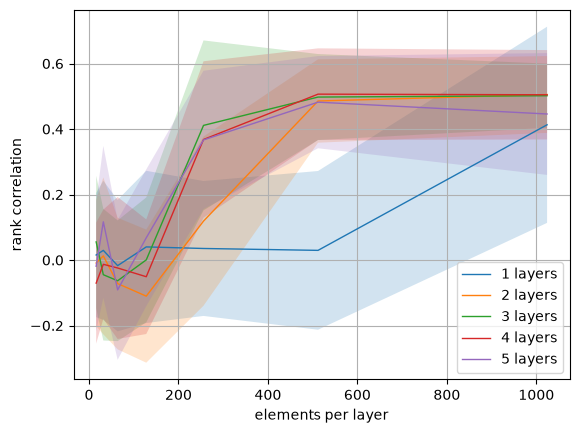

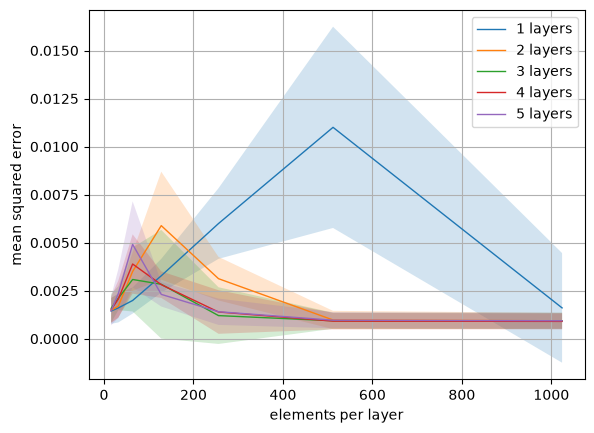

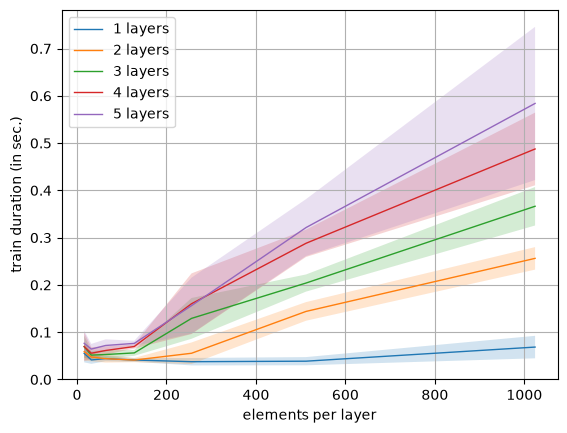

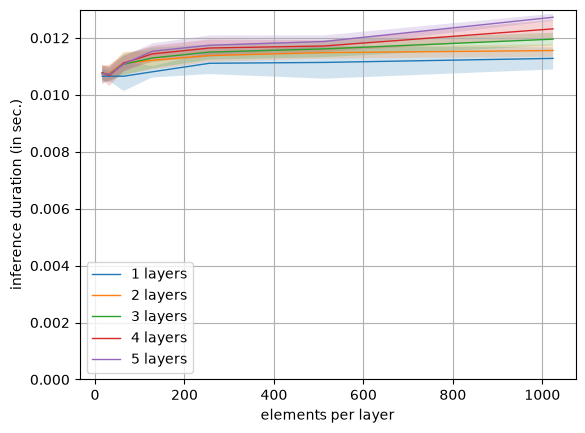

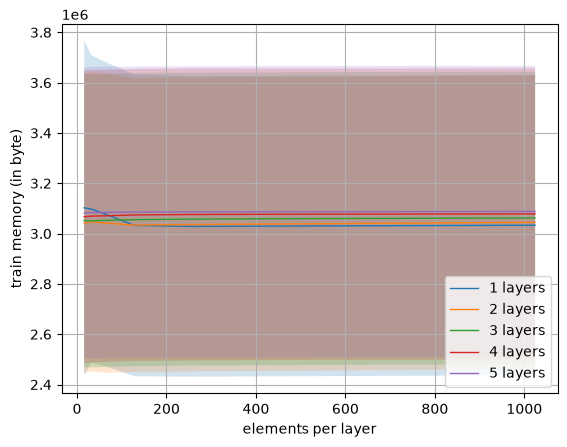

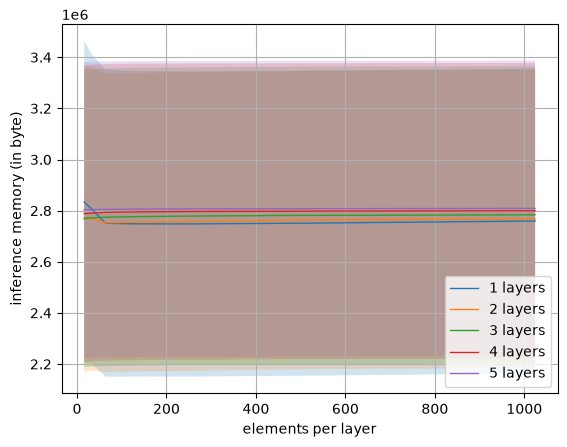


Results for 6 qubits and 15 gates:


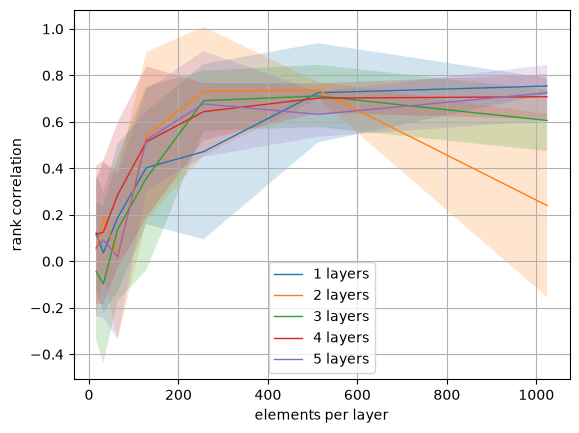

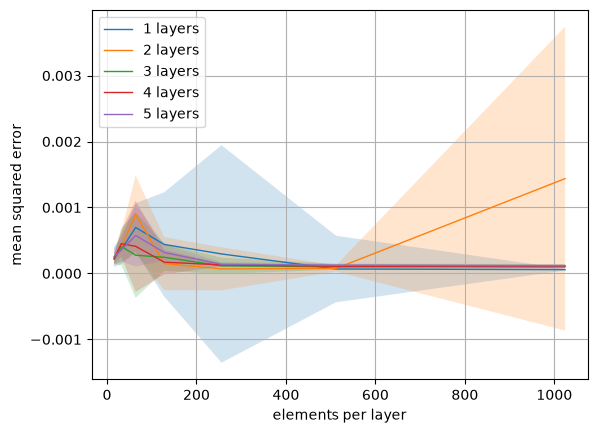

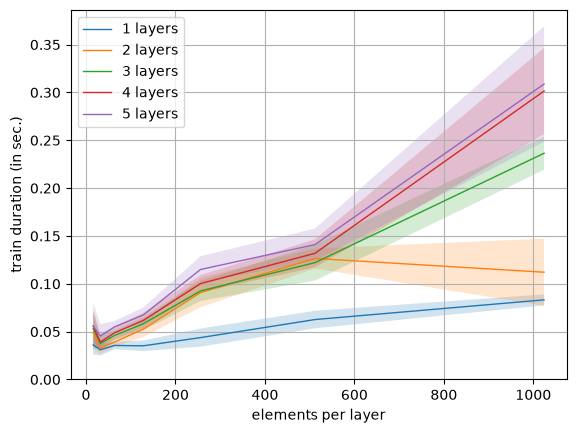

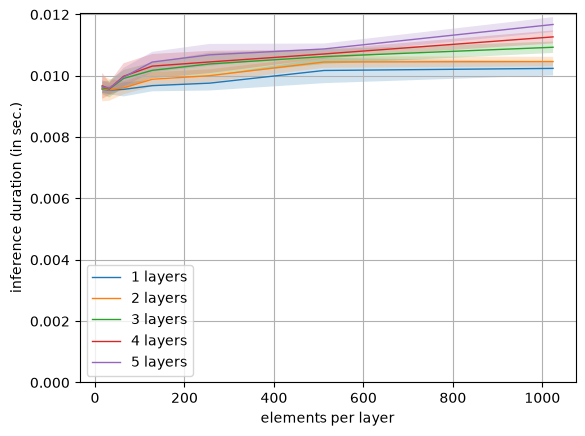

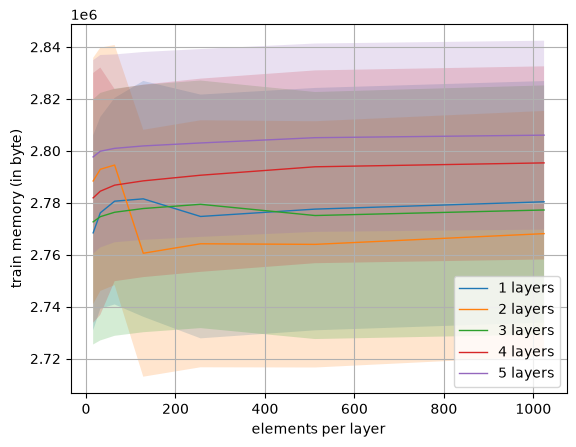

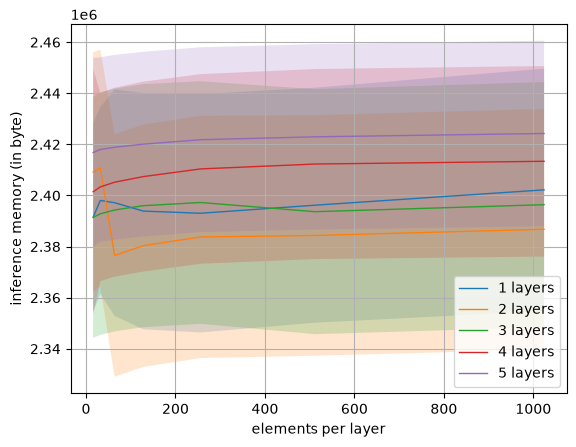


Results for 6 qubits and 20 gates:


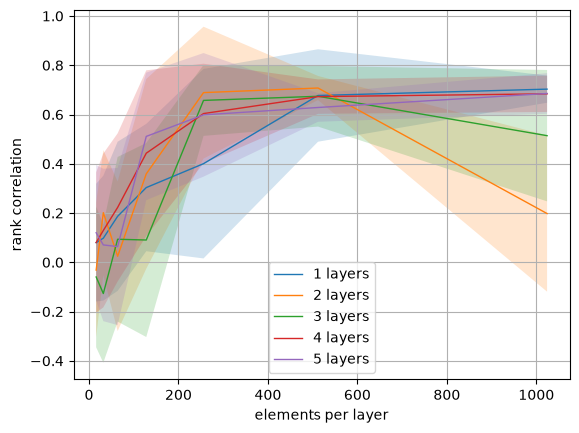

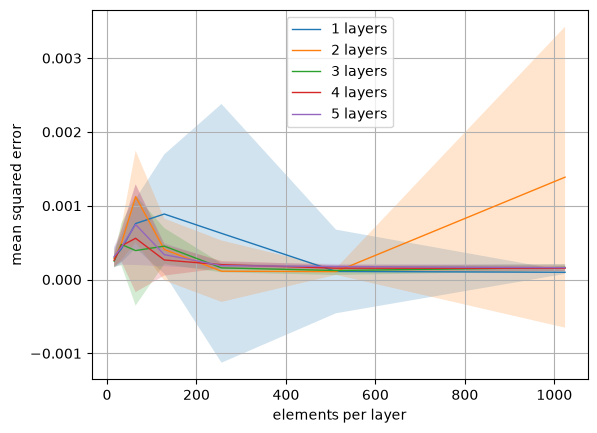

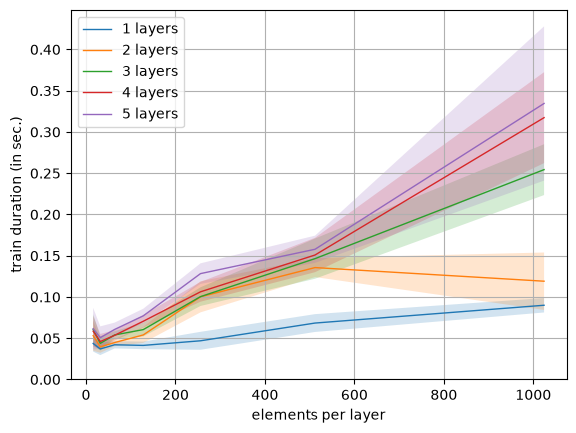

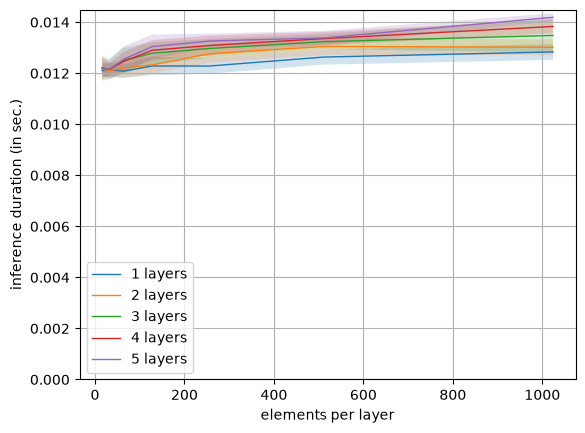

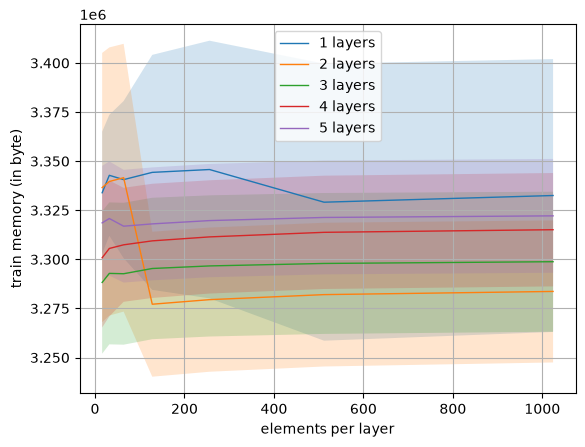

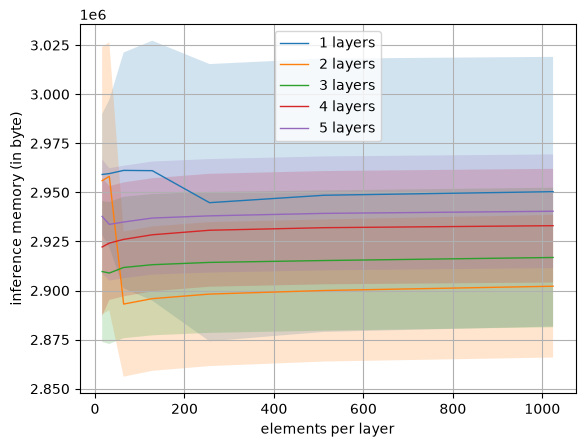


Results for 'model:  gnn'

Results for 4 qubits and 20 gates:


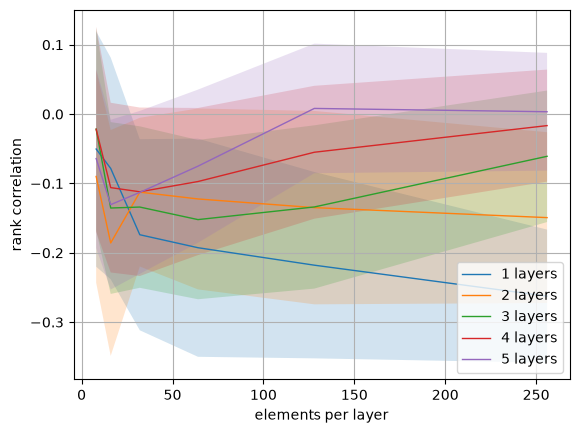

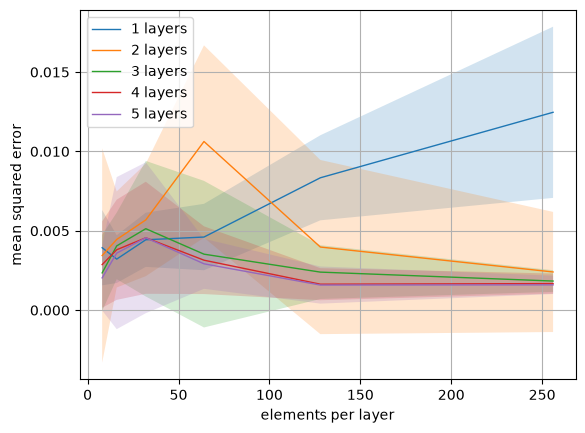

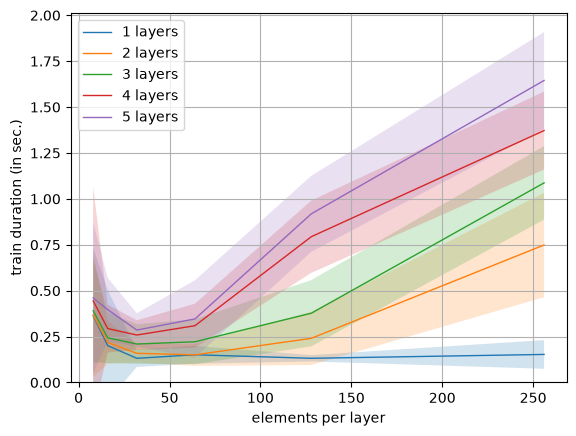

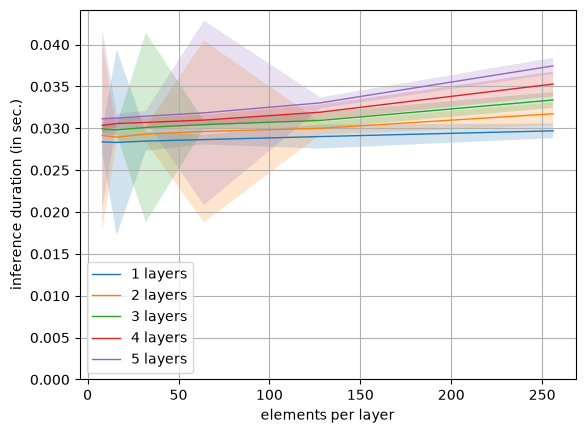

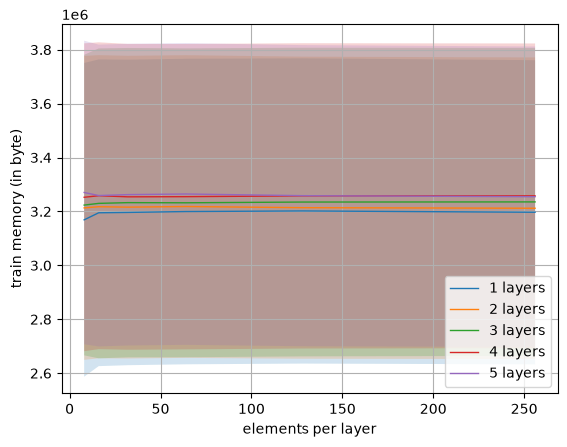

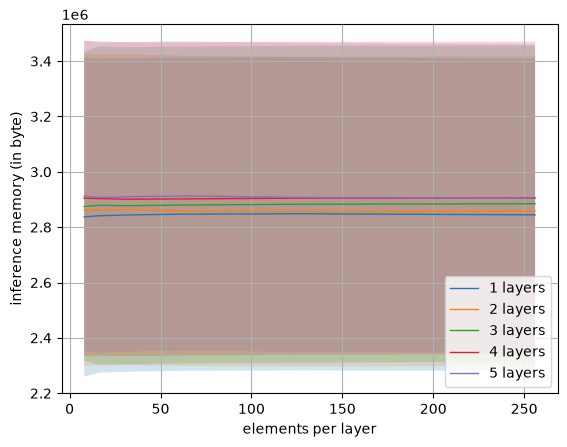


Results for 6 qubits and 15 gates:


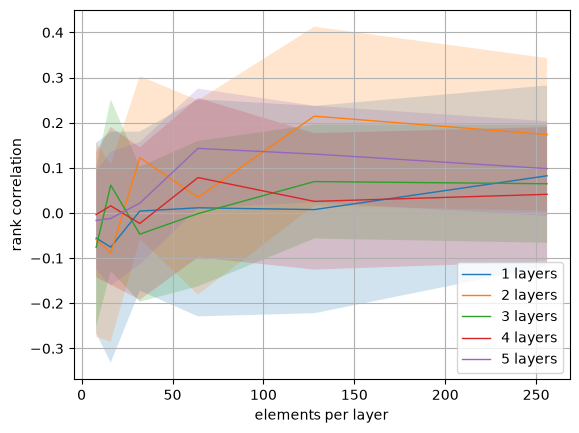

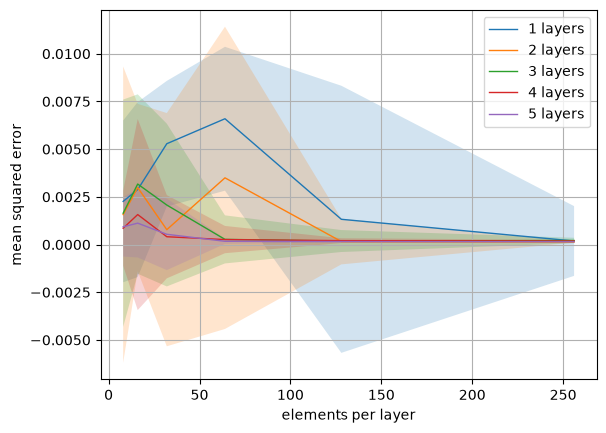

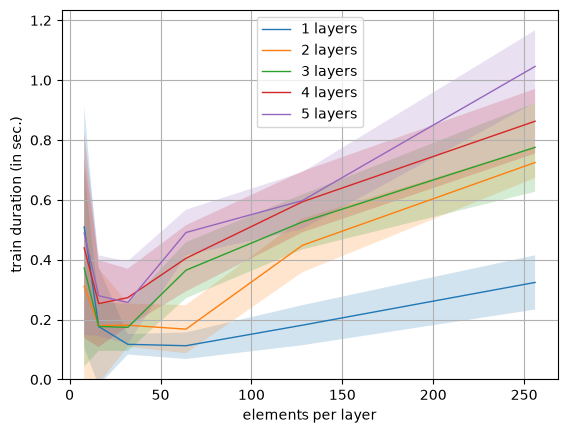

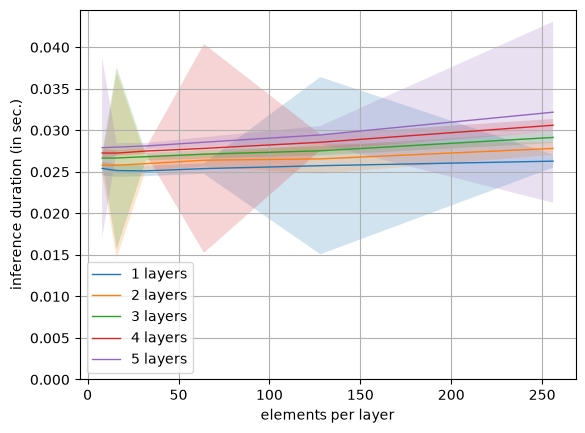

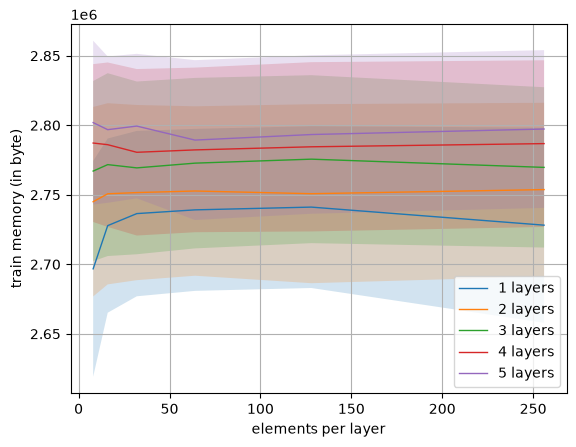

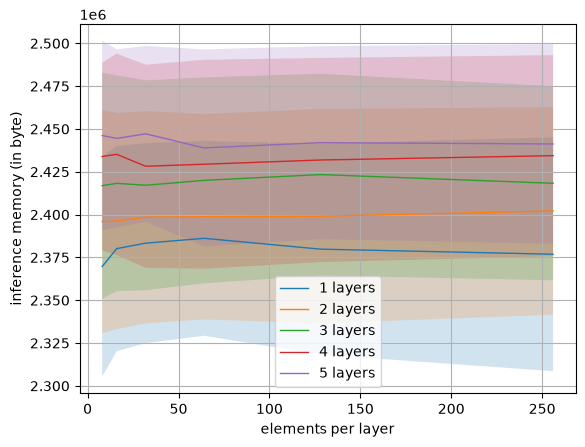


Results for 6 qubits and 20 gates:


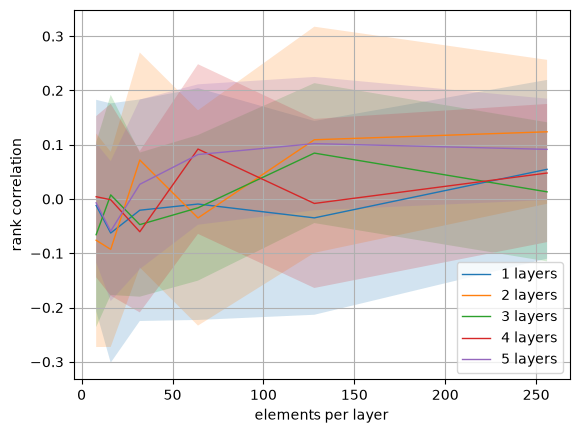

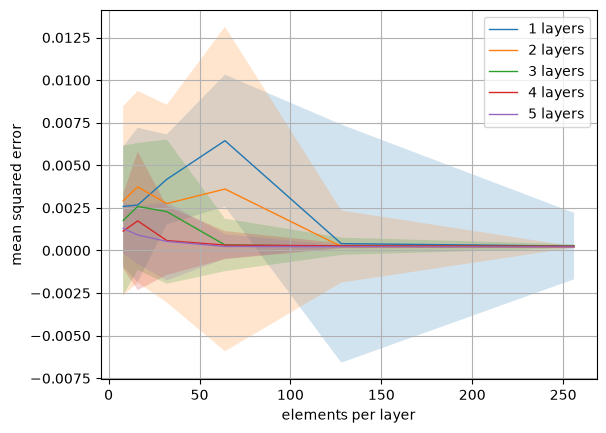

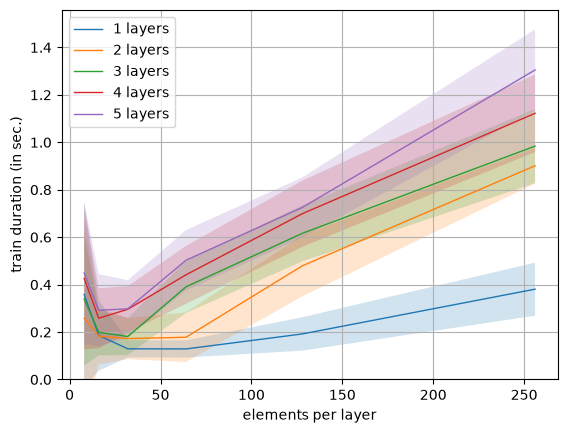

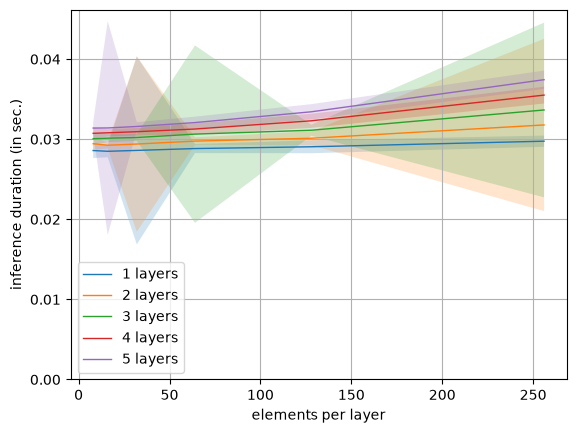

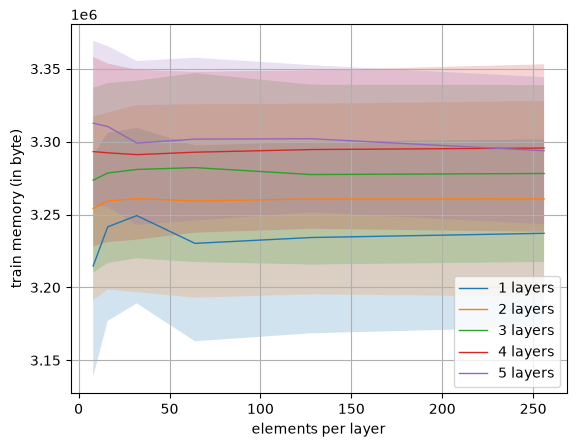

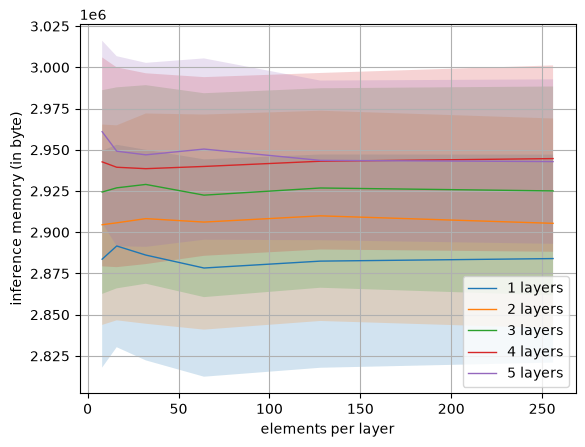

<Figure size 640x480 with 0 Axes>

In [14]:
for model in data["model"].unique():

    print("\n" + "=" * 20)
    print(f"Results for 'model: {model}'")
    print("=" * 20)


    for qubit_num in qubit_nums:

        for gate_count in gate_counts:

            rel_data = data[
                (data["qubit_num"] == qubit_num) & (data["gate_count"] == gate_count) & (data["model"] == model)
            ]

            if len(rel_data) == 0:
                continue

            print(f"\nResults for {qubit_num} qubits and {gate_count} gates:")
            plot_rank_correlation_as_lines(rel_data, target_path=f"results/as_{model}_{qubit_num}q{gate_count}g_rank_correlations.png", anchor_yaxis=False)
            plot_mse_as_lines(rel_data, target_path=f"results/as_{model}_{qubit_num}q{gate_count}g_mse.png", anchor_yaxis=False)
            plot_train_time_as_lines(rel_data, target_path=f"results/as_{model}_{qubit_num}q{gate_count}g_train_time.png")
            plot_inference_time_as_lines(rel_data, target_path=f"results/as_{model}_{qubit_num}q{gate_count}g_inference_time.png")
            plot_train_memory_as_lines(rel_data, anchor_yaxis=False)
            plot_inference_memory_as_lines(rel_data, anchor_yaxis=False)